<img src="../Decorative-Elements/Section-03/Section-03-04/Section-03-04-06.png">
<p style="display: flex; justify-content: space-between;">
  <a href="../03-Solar-System/04-Moon-Orbits-of-Each-Planet-05.ipynb" target="_blank">Previous</a>
  <a href="../03-Solar-System/04-Moon-Orbits-of-Each-Planet-07.ipynb" target="_blank">Next</a>
</p>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# Planet: Saturn

# Average distance from Sun: 9.58 AU
# Orbital period around Sun: 29.46 Earth years
# Orbital period in days: 10,759 days
# Total number of confirmed moons: 140+

# 29.46 Earth years is equivalent to approximately 10,759 days.
# Saturn takes significantly longer than Jupiter and Earth to complete one revolution around the Sun.

# Rotation period (one spin on its axis): 10.7 hours
# Saturn rotates rapidly compared to its long orbital period.

# Saturn is known for its prominent ring system.
# It is the second-largest planet in the Solar System.

# Major Moons:

# Titan
# Orbital period: 15.95 days
# Largest moon of Saturn
# Second-largest moon in the Solar System

# Rhea
# Orbital period: 4.52 days

# Iapetus
# Orbital period: 79.32 days
# Has one of the longest orbital periods among Saturn’s major moons

# Dione
# Orbital period: 2.74 days

# Enceladus
# Orbital period: 1.37 days
# Known for water-ice geysers

# Enceladus revolves fastest among the listed major moons.
# Iapetus has the longest orbital period among them.

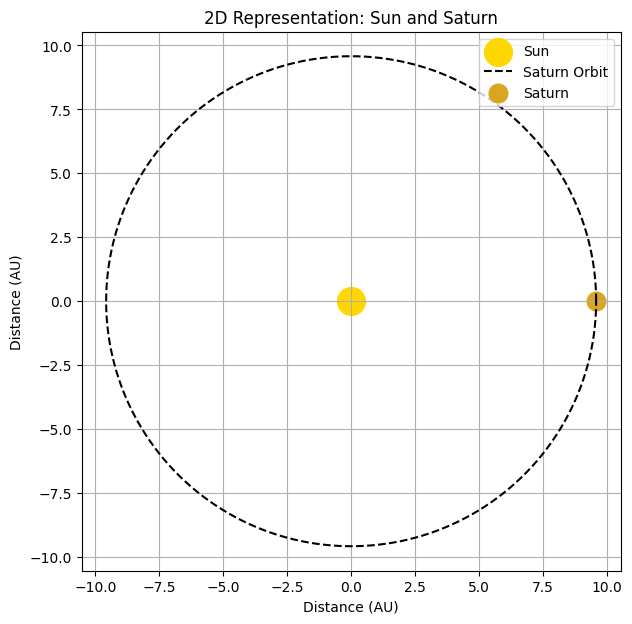

In [3]:
saturn_radius = 9.58  # AU

theta = np.linspace(0, 2*np.pi, 400)

x_orbit = saturn_radius * np.cos(theta)
y_orbit = saturn_radius * np.sin(theta)

plt.figure(figsize=(7,7))

# Sun
plt.scatter(0, 0, s=400, color='gold', label='Sun')

# Saturn orbit
plt.plot(x_orbit, y_orbit, linestyle='--', color='black', label='Saturn Orbit')

# Saturn position
plt.scatter(saturn_radius, 0, s=180, color='goldenrod', label='Saturn')

plt.gca().set_aspect('equal', 'box')
plt.title("2D Representation: Sun and Saturn")
plt.xlabel("Distance (AU)")
plt.ylabel("Distance (AU)")
plt.legend(loc='upper right')
plt.grid(True)

plt.show()

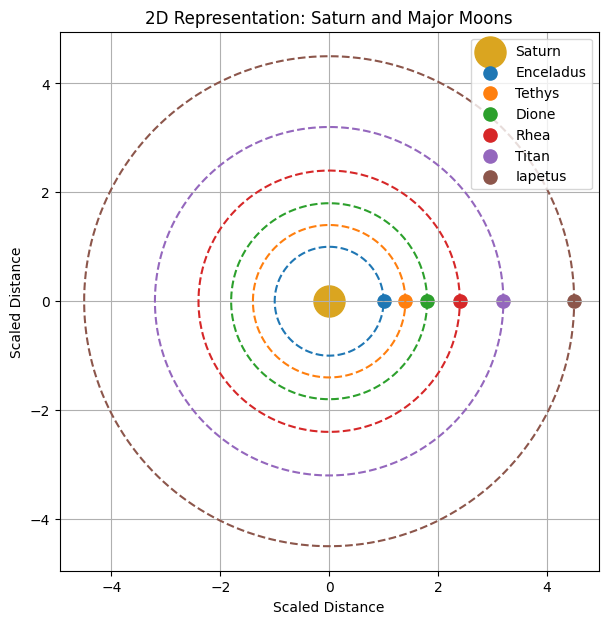

In [4]:
# Scaled orbital radii (not real AU, visual purpose only)
moon_radii = {
    "Enceladus": 1.0,
    "Tethys": 1.4,
    "Dione": 1.8,
    "Rhea": 2.4,
    "Titan": 3.2,
    "Iapetus": 4.5
}

theta = np.linspace(0, 2*np.pi, 400)

plt.figure(figsize=(7,7))

# Saturn at center
plt.scatter(0, 0, s=500, color='goldenrod', label='Saturn')

# Draw orbits and moon positions
for moon, radius in moon_radii.items():
    x_orbit = radius * np.cos(theta)
    y_orbit = radius * np.sin(theta)

    plt.plot(x_orbit, y_orbit, linestyle='--')
    plt.scatter(radius, 0, s=90, label=moon)

plt.gca().set_aspect('equal', 'box')
plt.title("2D Representation: Saturn and Major Moons")
plt.xlabel("Scaled Distance")
plt.ylabel("Scaled Distance")
plt.legend(loc='upper right')
plt.grid(True)

plt.show()

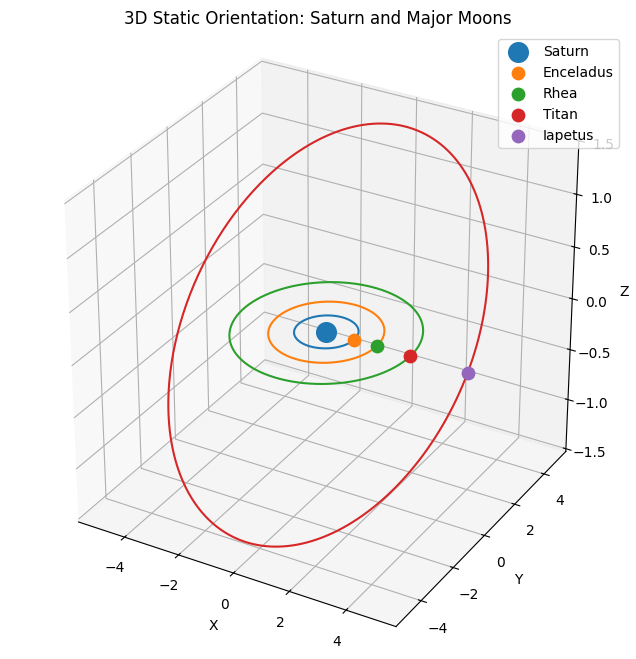

In [5]:
# Scaled orbital radii (visual purpose)
moon_data = {
    "Enceladus": (1.0, 0.02),
    "Rhea": (1.8, 0.35),
    "Titan": (3.0, 0.33),
    "Iapetus": (5.0, 15.47)
}

theta = np.linspace(0, 2*np.pi, 400)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# Saturn at origin
ax.scatter(0, 0, 0, s=200, label='Saturn')

for moon, (radius, inclination_deg) in moon_data.items():
    
    inc = np.radians(inclination_deg)
    
    # Base circular orbit in x-y plane
    x = radius * np.cos(theta)
    y = radius * np.sin(theta)
    z = np.zeros_like(theta)
    
    # Rotate orbit around x-axis to create inclination
    y_rot = y * np.cos(inc)
    z_rot = y * np.sin(inc)
    
    # Plot orbit
    ax.plot(x, y_rot, z_rot)
    
    # Plot moon at one position
    ax.scatter(radius, 0, 0, s=80, label=moon)

ax.set_title("3D Static Orientation: Saturn and Major Moons")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.legend(loc='upper right')

ax.set_box_aspect([1,1,1])

plt.show()

In [6]:
# Moon data: (scaled radius, actual inclination in degrees)
moon_data = {
    "Enceladus": (1.0, 0.02),
    "Rhea": (1.8, 0.35),
    "Titan": (3.0, 0.33),
    "Iapetus": (5.0, 15.47)
}

theta = np.linspace(0, 2*np.pi, 400)

fig = go.Figure()

# Saturn at origin
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers',
    marker=dict(size=20),
    name='Saturn'
))

for moon, (radius, inc_deg) in moon_data.items():
    inc = np.radians(inc_deg)  # inclination
    
    # Base orbit in xy-plane
    x = radius * np.cos(theta)
    y_base = radius * np.sin(theta)
    z_base = np.zeros_like(theta)
    
    # Inclined orbit (rotate about x-axis)
    y_rot = y_base * np.cos(inc)
    z_rot = y_base * np.sin(inc)
    
    # Orbit line
    fig.add_trace(go.Scatter3d(
        x=x, y=y_rot, z=z_rot,
        mode='lines',
        line=dict(width=2),
        name=f"{moon} Orbit"
    ))
    
    # Moon position at theta = 0
    fig.add_trace(go.Scatter3d(
        x=[radius], y=[0], z=[0],
        mode='markers',
        marker=dict(size=6),
        name=moon
    ))

# Layout
fig.update_layout(
    title="3D Static Orientation: Saturn and Major Moons",
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='data'
    ),
    width=800,
    height=800,
    showlegend=True
)

fig.show()

# Output is not visible in github webpage, refer to Folder/Output-Plotly

<p style="display: flex; justify-content: space-between;">
  <a href="../03-Solar-System/04-Moon-Orbits-of-Each-Planet-05.ipynb" target="_blank">Previous</a>
  <a href="../03-Solar-System/04-Moon-Orbits-of-Each-Planet-07.ipynb" target="_blank">Next</a>
</p>

<img src="../Decorative-Elements/Section-Footer-Animated/Section-03-04/Section-03-04-f.gif">